In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../../../../dataset/nf_uq_balanced_dataset.parquet"
raw_data = pd.read_parquet(DATA_PATH)
df = raw_data.copy()
pd.set_option('display.max_columns', None)
df


,L4_SRC_PORT,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,DURATION_IN,DURATION_OUT,MIN_TTL,MAX_TTL,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,RETRANSMITTED_IN_BYTES,RETRANSMITTED_IN_PKTS,RETRANSMITTED_OUT_BYTES,RETRANSMITTED_OUT_PKTS,SRC_TO_DST_AVG_THROUGHPUT,DST_TO_SRC_AVG_THROUGHPUT,NUM_PKTS_UP_TO_128_BYTES,NUM_PKTS_128_TO_256_BYTES,NUM_PKTS_256_TO_512_BYTES,NUM_PKTS_512_TO_1024_BYTES,NUM_PKTS_1024_TO_1514_BYTES,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,Label,Dataset
0,19094,80,6,7.000,420,3,0,0,2,2,0,4293024,1943,0,64,64,140,140,0,140,140280.0,0.0,140,1,0,0,1120000,0,0,3,0,0,0,512,0,35840,140,0,0,0,0.0,DoS,NaN
1,33720,80,6,7.000,140,1,0,0,2,2,0,0,0,0,0,0,140,140,0,140,140.0,0.0,0,0,0,0,1120000,0,0,1,0,0,0,512,0,0,0,0,0,0,0.0,DoS,NaN
2,62243,53,17,0.000,68,1,84,1,0,0,0,0,0,0,0,0,84,68,68,84,68.0,84.0,0,0,0,0,544000,672000,2,0,0,0,0,0,0,0,0,40768,1,20,0.0,Benign,NaN
3,50028,3389,6,0.000,1476,8,1873,7,222,222,90,0,0,0,96,96,1213,40,40,1213,1476.0,1873.0,0,0,0,0,11808000,14984000,10,2,1,1,1,8192,64000,0,0,0,0,0,0.0,Benign,NaN
4,42056,21,6,1.000,840,14,560,14,22,2,20,4294701,266,266,63,63,60,40,40,60,840.0,560.0,0,0,0,0,24000,16000,28,0,0,0,0,26883,0,0,0,0,0,0,0.0,Brute Force,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1240337,21676,21,6,1.000,2059,37,2816,39,24,24,24,4294952,15,15,31,32,106,52,52,106,2506.0,3058.0,505,8,887,10,808000,944000,87,0,0,0,0,21720,18824,63744,249,0,0,0,125.0,Benign,NaN
1240338,57089,53,17,5.126,63,1,79,1,0,0,0,0,0,0,0,0,79,63,63,79,63.0,79.0,0,0,0,0,504000,632000,2,0,0,0,0,0,0,0,0,23827,1,60,0.0,Benign,NaN
1240339,59600,53,17,0.000,74,1,90,1,0,0,0,0,0,0,0,0,90,74,74,90,74.0,90.0,0,0,0,0,592000,720000,2,0,0,0,0,0,0,0,0,30933,1,60,0.0,Benign,NaN
1240340,23461,80,6,7.000,280,2,0,0,2,2,0,4292920,2047,0,64,64,140,140,0,140,140140.0,0.0,140,1,0,0,1120000,0,0,2,0,0,0,512,0,35840,140,0,0,0,0.0,DoS,NaN


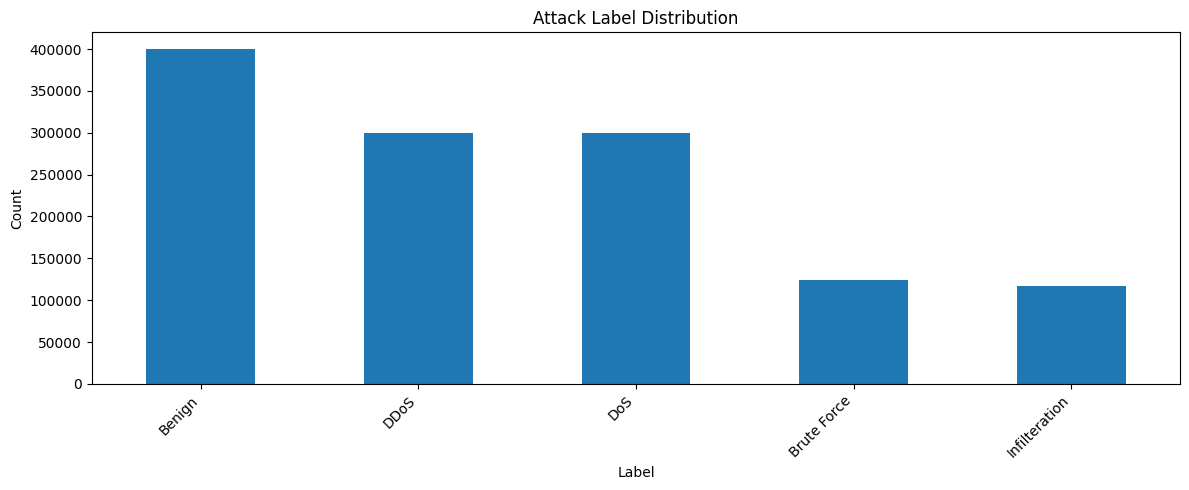

In [2]:
# Label distribution
label_counts = df['Label'].value_counts()

plt.figure(figsize=(12, 5))
label_counts.plot(kind='bar')
plt.title('Attack Label Distribution')
plt.xlabel('Label'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


In [3]:

# ── Group similar attack types ───────────────────────────────────────────────
attack_group_mapping = {
    # # BENIGN
    'Benign': 'BENIGN',
    'DDoS': 'DDoS',
    'DoS': 'DoS',
    'Brute Force': 'Brute Force',
    'Infilteration': 'Infiltration',
}

# Apply mapping; rows with unmapped labels are dropped
df['Label'] = df['Label'].map(attack_group_mapping)
df.dropna(subset=['Label'], inplace=True)

print(f"Groups after mapping : {df['Label'].nunique()}")
for g, cnt in df['Label'].value_counts().items():
    print(f"  {g:<20} {cnt:>10,}  ({cnt/len(df)*100:.2f}%)")


Groups after mapping : 5
  BENIGN                  400,000  (32.25%)
  DDoS                    300,000  (24.19%)
  DoS                     299,999  (24.19%)
  Brute Force             123,982  (10.00%)
  Infiltration            116,361  (9.38%)


In [4]:
# Handle inf → NaN → median fill
df_processed = df.replace([np.inf, -np.inf], np.nan)

for col in df_processed.select_dtypes(include=[np.number]).columns:
    if df_processed[col].isnull().any():
        med = df_processed[col].median()
        df_processed[col] = df_processed[col].fillna(med if pd.notna(med) else 0)

# Drop any remaining all-NaN columns (non-numeric)
all_nan_cols = [c for c in df_processed.columns if df_processed[c].isnull().all()]
if all_nan_cols:
    print(f"Dropping all-NaN columns: {all_nan_cols}")
    df_processed.drop(columns=all_nan_cols, inplace=True)

remaining_nan = df_processed.isnull().sum().sum()
print(f"Shape: {df_processed.shape}  |  NaN remaining: {remaining_nan}")
assert remaining_nan == 0, "NaN values still present — check the data!"


Shape: (1240342, 43)  |  NaN remaining: 0


/home/huyho/.local/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [5]:
# Drop metadata columns
keywords = ['flow id', 'flow_id', 'source ip', 'destination ip',
            'src ip', 'dst ip', 'timestamp', 'source port', 'dst port']
cols_to_drop = [c for c in df_processed.columns if any(k in c.lower() for k in keywords)]
df_processed.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f"Shape: {df_processed.shape}")


Shape: (1240342, 43)


In [6]:
# Encode labels
from sklearn.preprocessing import LabelEncoder
import pickle

le = LabelEncoder()
df_processed['Label_Encoded'] = le.fit_transform(df_processed['Label'])

with open('label_encoder.pkl1', 'wb') as f:
    pickle.dump(le, f)

print(dict(zip(le.classes_, range(len(le.classes_)))))


{'BENIGN': 0, 'Brute Force': 1, 'DDoS': 2, 'DoS': 3, 'Infiltration': 4}


In [7]:
# Train / test split (stratified 80/20)
from sklearn.model_selection import train_test_split

X = df_processed.drop(['Label', 'Label_Encoded'], axis=1)
y = df_processed['Label_Encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


Train: (992273, 42)  |  Test: (248069, 42)


In [8]:
# Feature scaling
from sklearn.preprocessing import StandardScaler

# Drop zero-variance columns (StandardScaler would produce NaN for them)
zero_var_cols = [c for c in X_train.columns if X_train[c].std() == 0]
if zero_var_cols:
    print(f"Dropping {len(zero_var_cols)} zero-variance columns: {zero_var_cols}")
    X_train = X_train.drop(columns=zero_var_cols)
    X_test  = X_test.drop(columns=zero_var_cols)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns,  index=X_test.index)

with open('scaler.pkl1', 'wb') as f:
    pickle.dump(scaler, f)

print(f"Train: {X_train_scaled.shape}  |  Test: {X_test_scaled.shape}")


Dropping 1 zero-variance columns: ['Dataset']


/home/huyho/.local/lib/python3.10/site-packages/pandas/core/nanops.py:1025: RuntimeWarning: overflow encountered in cast
  result = result.astype(dtype, copy=False)


Train: (992273, 41)  |  Test: (248069, 41)


In [9]:
# RFE — sweep k (proxy: DecisionTree for selection, KNN for evaluation)
from sklearn.feature_selection import RFE, RFECV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

knn_baseline = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_baseline.fit(X_train_scaled, y_train)
test_acc = accuracy_score(y_test, knn_baseline.predict(X_test_scaled))

# KNN has no coef_/feature_importances_, use DecisionTree as proxy for RFE ranking
proxy = DecisionTreeClassifier(max_depth=10, random_state=42)
k_values = [k for k in [10, 20, 30, 40, 50, 60, 70] if k < X_train_scaled.shape[1]]
rfe_results = {}

for k in k_values:
    rfe = RFE(estimator=proxy, n_features_to_select=k, step=140)
    rfe.fit(X_train_scaled, y_train)
    knn_k = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    knn_k.fit(X_train_scaled.iloc[:, rfe.support_], y_train)
    rfe_results[k] = {'accuracy': accuracy_score(y_test, knn_k.predict(X_test_scaled.iloc[:, rfe.support_])), 'support': rfe.support_}

best_k = max(rfe_results, key=lambda k: rfe_results[k]['accuracy'])
print(f"Baseline: {test_acc*100:.2f}%  |  Best k={best_k}: {rfe_results[best_k]['accuracy']*100:.2f}%")


Baseline: 91.68%  |  Best k=30: 91.86%


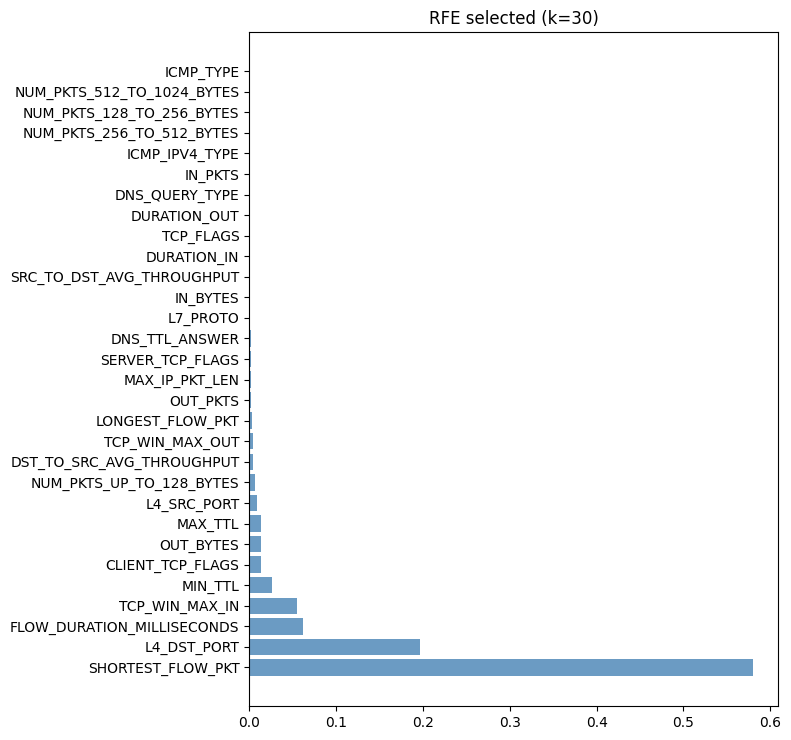

=== RFE k=30 Features (by DT proxy importance) ===
   1. SHORTEST_FLOW_PKT                             importance=0.5798
   2. L4_DST_PORT                                   importance=0.1964
   3. FLOW_DURATION_MILLISECONDS                    importance=0.0617
   4. TCP_WIN_MAX_IN                                importance=0.0556
   5. MIN_TTL                                       importance=0.0257
   6. CLIENT_TCP_FLAGS                              importance=0.0140
   7. OUT_BYTES                                     importance=0.0132
   8. MAX_TTL                                       importance=0.0131
   9. L4_SRC_PORT                                   importance=0.0084
  10. NUM_PKTS_UP_TO_128_BYTES                      importance=0.0068
  11. DST_TO_SRC_AVG_THROUGHPUT                     importance=0.0041
  12. TCP_WIN_MAX_OUT                               importance=0.0040
  13. LONGEST_FLOW_PKT                              importance=0.0027
  14. OUT_PKTS                         

In [10]:

# Feature ranking (RFE best_k) — importance via DT proxy
best_rfe = RFE(estimator=DecisionTreeClassifier(max_depth=10, random_state=42),
               n_features_to_select=best_k, step=140)
best_rfe.fit(X_train_scaled, y_train)

rfe_features = X_train_scaled.columns[best_rfe.support_].tolist()
importances = best_rfe.estimator_.feature_importances_
selected_df = pd.DataFrame({'Feature': rfe_features, 'Importance': importances}) \
                .sort_values('Importance', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, max(4, best_k * 0.25)))
ax.barh(selected_df['Feature'], selected_df['Importance'], color='steelblue', alpha=0.8)
ax.set_title(f'RFE selected (k={best_k})'); ax.invert_yaxis()
plt.tight_layout(); plt.show()

# ── Reuse best_rfe for cross-dataset validation (no re-training) ──────────────
import pickle

knn_rfe = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_rfe.fit(X_train_scaled[rfe_features], y_train)

rfe_sorted = pd.Series(best_rfe.estimator_.feature_importances_,
                        index=rfe_features).sort_values(ascending=False)

print(f"=== RFE k={best_k} Features (by DT proxy importance) ===")
for i, (feat, imp) in enumerate(rfe_sorted.items(), 1):
    print(f"  {i:2d}. {feat:<45} importance={imp:.4f}")

with open('knn_rfe20_model.pkl', 'wb') as f: pickle.dump(knn_rfe, f)
with open('rfe20_selected_features.pkl', 'wb') as f: pickle.dump(rfe_features, f)


In [11]:

# ── Classification report ─────────────────────────────────────────────────────
y_test_pred = knn_rfe.predict(X_test_scaled[rfe_features])
print(classification_report(y_test, y_test_pred, target_names=le.classes_, digits=4, zero_division=0))


              precision    recall  f1-score   support

      BENIGN     0.8686    0.9013    0.8846     80000
 Brute Force     0.9953    0.9795    0.9873     24797
        DDoS     0.9859    0.9904    0.9881     60000
         DoS     0.9904    0.9932    0.9918     60000
Infiltration     0.6172    0.5363    0.5739     23272

    accuracy                         0.9186    248069
   macro avg     0.8915    0.8801    0.8852    248069
weighted avg     0.9155    0.9186    0.9167    248069



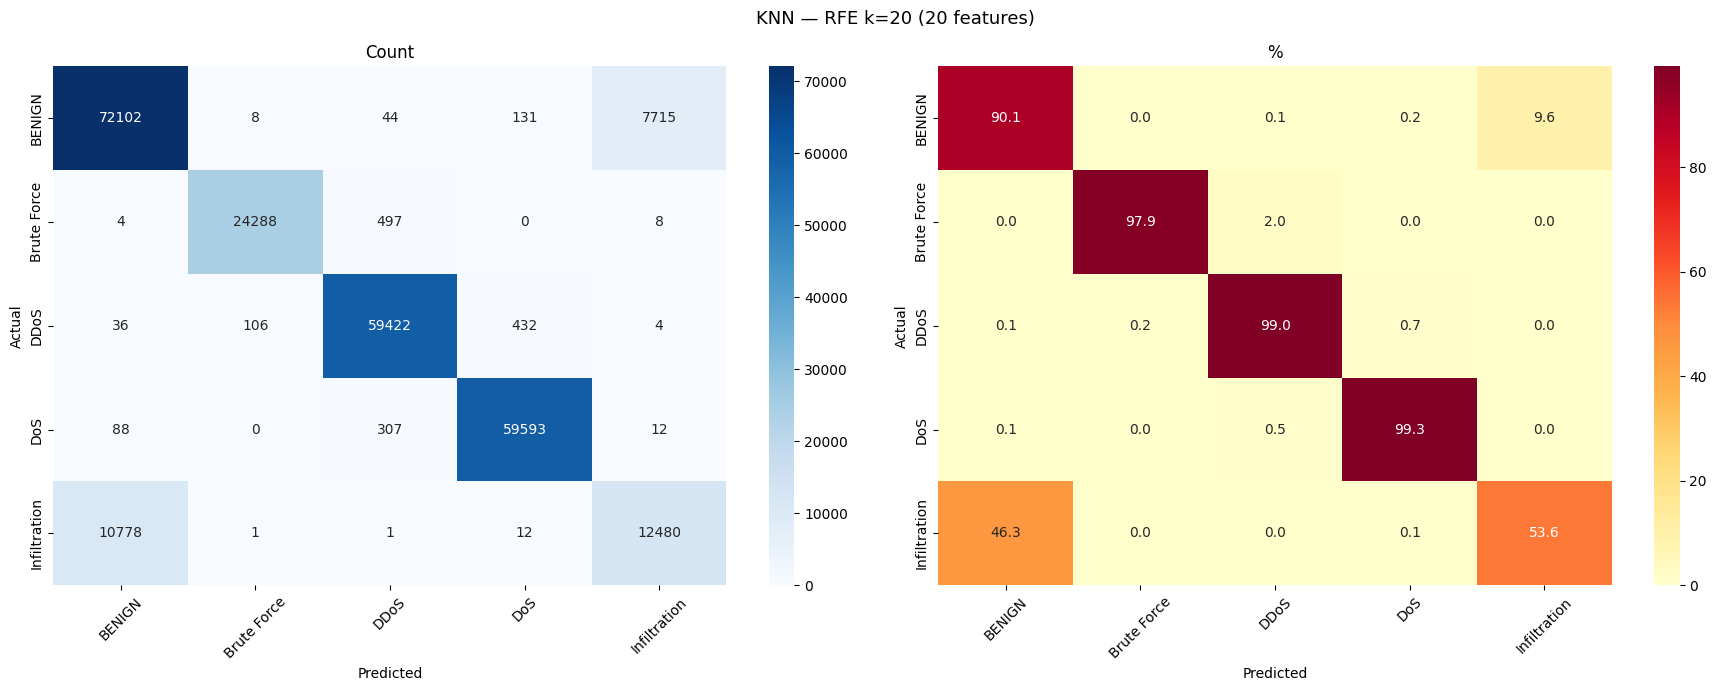

In [12]:

# Confusion matrix — RFE k=20 model
cm = confusion_matrix(y_test, knn_rfe.predict(X_test_scaled[rfe_features]))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=ax1)
ax1.set_title('Count'); ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual'); ax1.tick_params(axis='x', rotation=45)

sns.heatmap(cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax2)
ax2.set_title('%'); ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual'); ax2.tick_params(axis='x', rotation=45)

plt.suptitle('KNN — RFE k=20 (20 features)', fontsize=13)
plt.tight_layout(); plt.show()
